In [ ]:
import sqlite3
import pandas as pd
import pm4py
from pathlib import Path


In [ ]:
from pathlib import Path

sqlite_path = Path(__file__).resolve().parent / "data" / "ocel2-p2p.sqlite"
conn = sqlite3.connect(sqlite_path)
cursor = conn.cursor()

print("="*60)
print("DATABASE OVERVIEW")
print("="*60)
tables = pd.read_sql("""
SELECT name 
FROM sqlite_master 
WHERE type='table'
ORDER BY name;
""", conn)

print("\nTables:")
print(tables.to_string(index=False))

print("\n" + "="*60)
print("TABLE SCHEMAS")
print("="*60)

for table in tables["name"]:
    print(f"\n--- {table} ---")

    schema = pd.read_sql(f"PRAGMA table_info({table});", conn)
    print(schema[["name", "type", "notnull"]])

print("\n" + "="*60)
print("ROW COUNTS")
print("="*60)

for table in tables["name"]:
    count = pd.read_sql(f"SELECT COUNT(*) AS n FROM {table};", conn)
    print(f"{table:40s} -> {count['n'][0]}")

print("\n" + "="*60)
print("SAMPLE DATA")
print("="*60)

for table in tables["name"]:
    print(f"\nSample from {table}:")
    try:
        sample = pd.read_sql(f"SELECT * FROM {table} LIMIT 5;", conn)
        print(sample)
    except Exception as e:
        print("Could not read:", e)
        
sample = pd.read_sql(f"SELECT distinct ocel_type FROM event;", conn)
sample_count = pd.read_sql(f"SELECT COUNT(*) AS n FROM event;", conn)

print("\nPossible event types:")
print(sample)
print(f"\nRow count for event table: {sample_count['n'][0]}")


DATABASE OVERVIEW

Tables:
                                     name
                                    event
               event_ApprovePurchaseOrder
         event_ApprovePurchaseRequisition
                 event_CreateGoodsReceipt
               event_CreateInvoiceReceipt
                event_CreatePurchaseOrder
          event_CreatePurchaseRequisition
          event_CreateRequestforQuotation
event_DelegatePurchaseRequisitionApproval
                     event_ExecutePayment
                 event_PerformTwoWayMatch
                           event_map_type
                             event_object
                                   object
                      object_goodsreceipt
                    object_invoicereceipt
                          object_map_type
                          object_material
                            object_object
                           object_payment
                    object_purchase_order
              object_purchase_requisition
       

In [29]:
sample = pd.read_sql(f"SELECT count(*) FROM (SELECT distinct * FROM object_material) AS subquery;", conn)
print(sample)


   count(*)
0      2296


In [3]:
ocel = pm4py.read_ocel2_sqlite(sqlite_path)
print(ocel)

Object-Centric Event Log (number of events: 14671, number of objects: 9054, number of activities: 10, number of object types: 7, events-objects relationships: 35927)
Activities occurrences: Counter({'Create Goods Receipt': 4042, 'Create Invoice Receipt': 1941, 'Perform Two-Way Match': 1941, 'Create Purchase Order': 1598, 'Approve Purchase Order': 1598, 'Execute Payment': 1166, 'Create Request for Quotation': 927, 'Create Purchase Requisition': 729, 'Approve Purchase Requisition': 607, 'Delegate Purchase Requisition Approval': 122})
Object types occurrences (number of objects): Counter({'goods receipt': 1941, 'material': 1807, 'purchase_order': 1598, 'invoice receipt': 927, 'payment': 927, 'purchase_requisition': 927, 'quotation': 927})
Unique activities per object type: Counter({'goods receipt': 4, 'purchase_order': 4, 'purchase_requisition': 4, 'invoice receipt': 3, 'material': 3, 'quotation': 3, 'payment': 1})
Please use <THIS>.get_extended_table() to get a dataframe representation o

pm4js

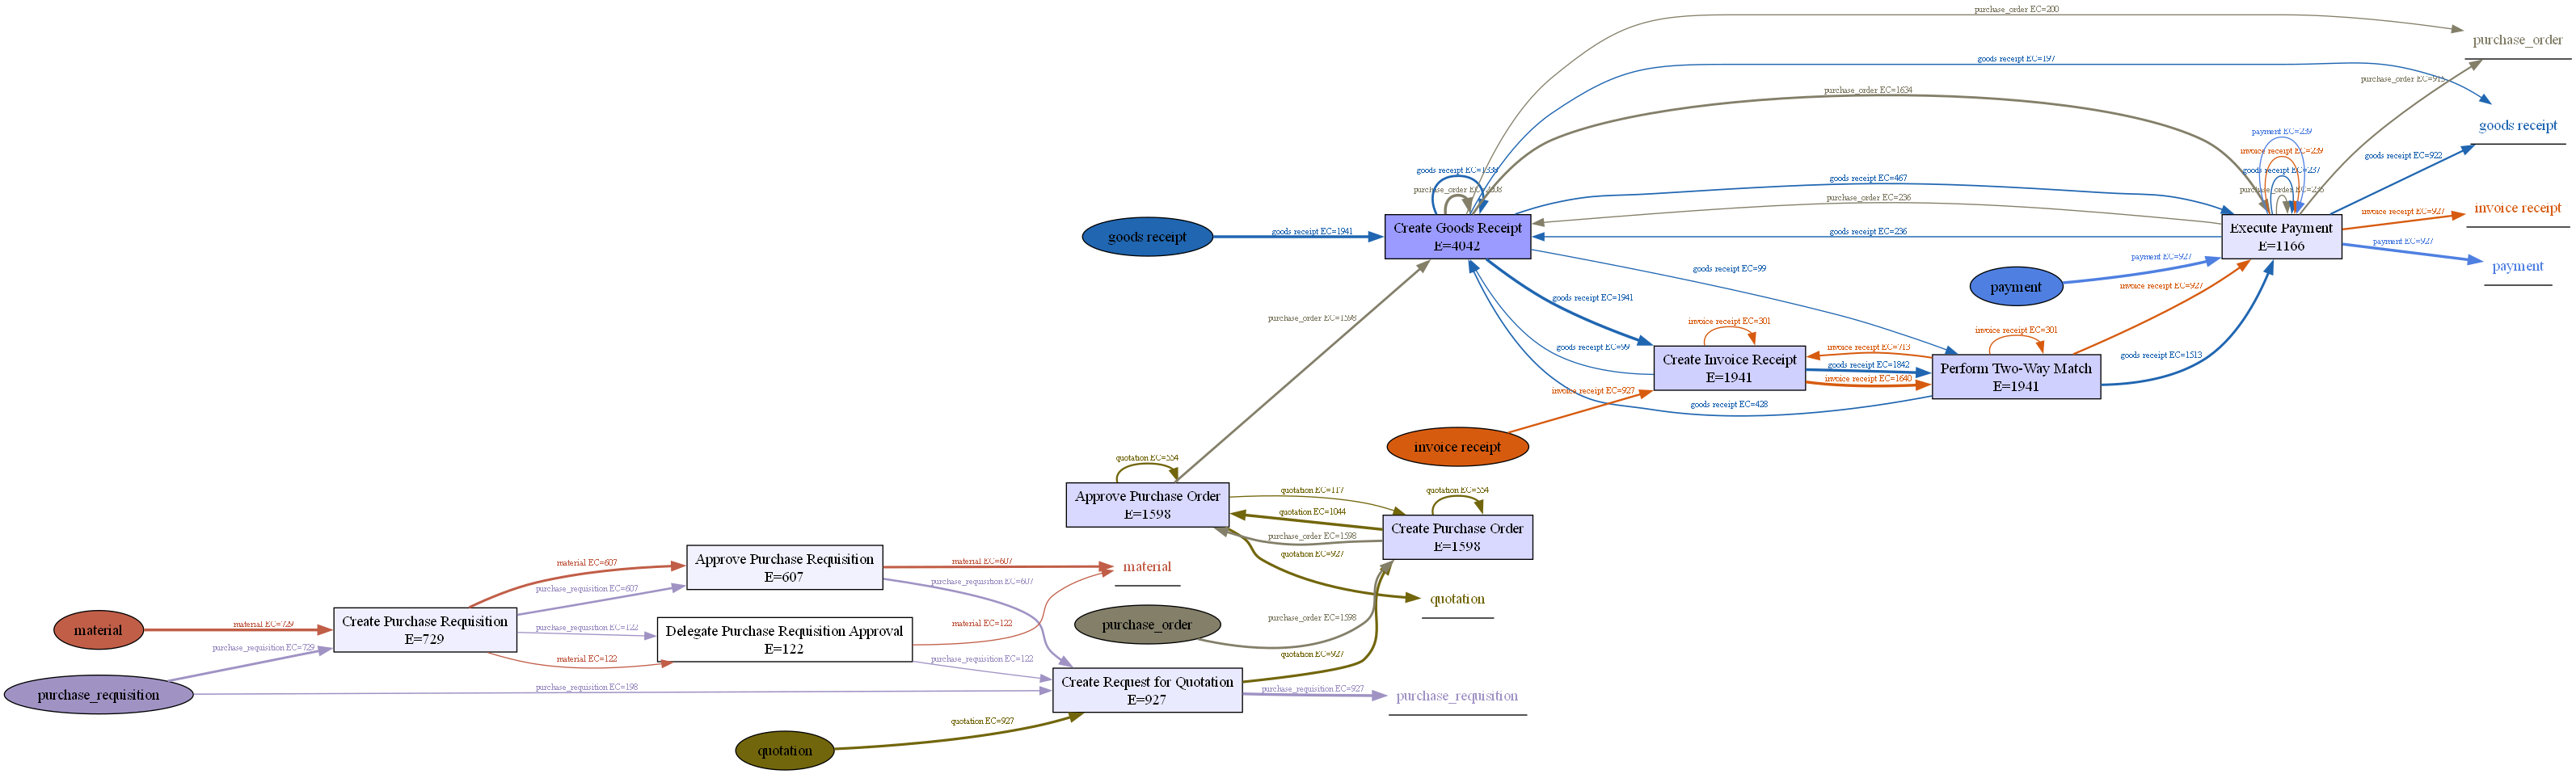

In [4]:
ocdfg = pm4py.discover_ocdfg(ocel)

pm4py.view_ocdfg(ocdfg)

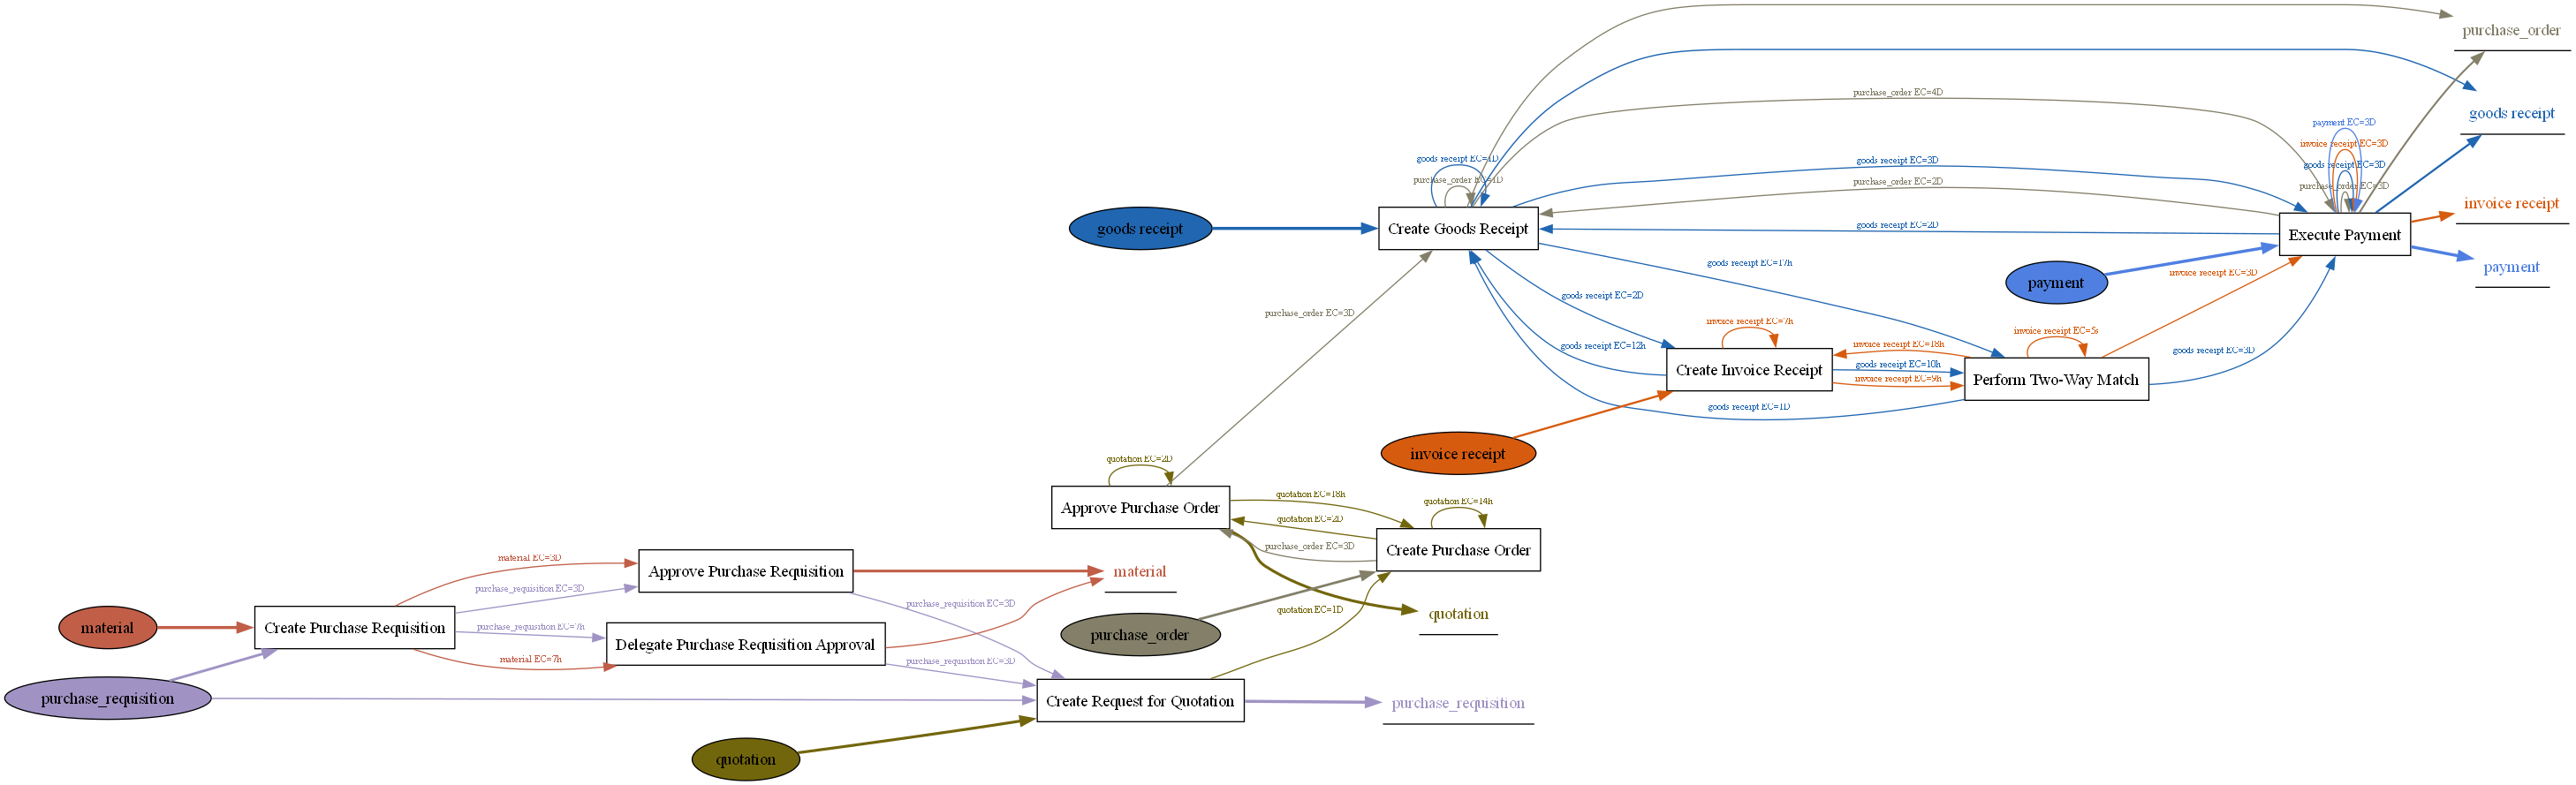

In [18]:
ocdfg_perf = pm4py.discover_ocdfg(ocel)

pm4py.view_ocdfg(ocdfg_perf, annotation="performance")

In [19]:
ocpn = pm4py.discover_oc_petri_net(ocel)

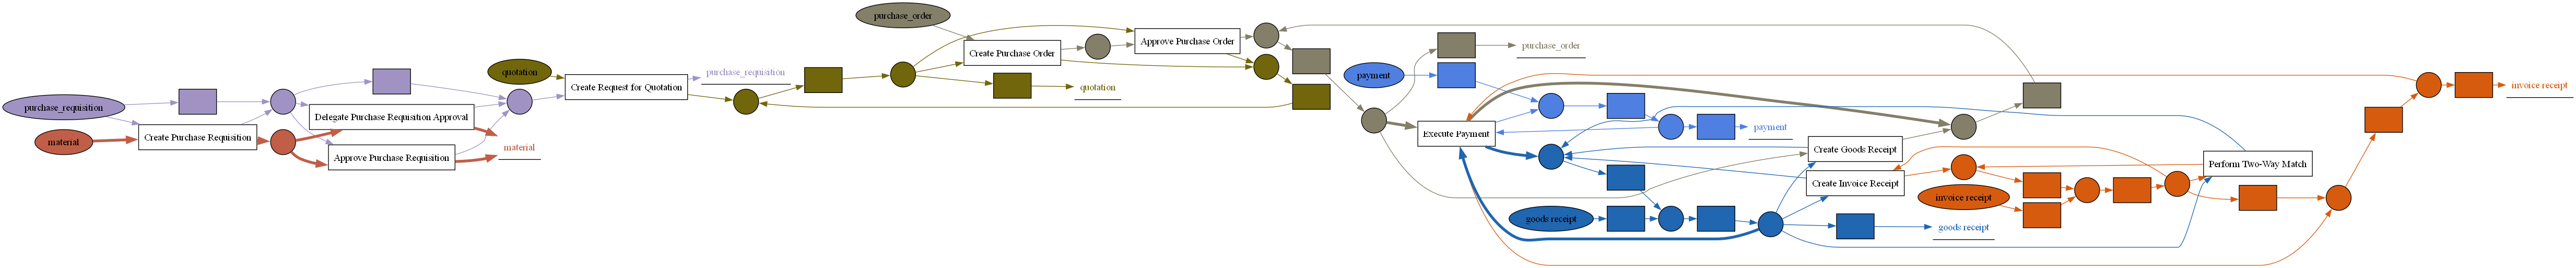

In [7]:
pm4py.view_ocpn(ocpn)

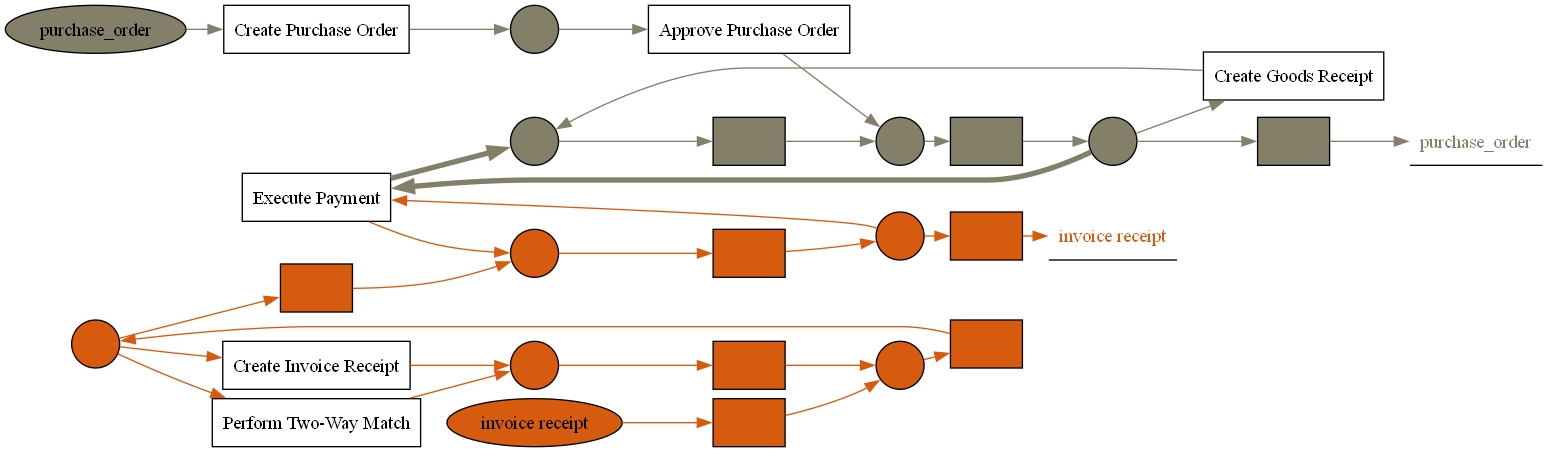

In [12]:
# Focus only on the relation between PO and Invoice
filtered_ocel = pm4py.filter_ocel_object_types(ocel, ["purchase_order", "invoice receipt"])
ocpn_filtered = pm4py.discover_oc_petri_net(filtered_ocel)
pm4py.view_ocpn(ocpn_filtered)

In [8]:
import numpy as np

def remove_events(conn, gamma=0.1, seed=42):
    np.random.seed(seed)

    events = pd.read_sql("SELECT ocel_id FROM event", conn)

    remove_ids = events.sample(frac=gamma)["ocel_id"].tolist()

    conn.execute(
        "DELETE FROM event WHERE ocel_id IN ({})"
        .format(",".join(["?"]*len(remove_ids))),
        remove_ids
    )

    conn.execute(
        "DELETE FROM event_object WHERE ocel_event_id IN ({})"
        .format(",".join(["?"]*len(remove_ids))),
        remove_ids
    )

    conn.commit()

In [9]:
def remove_timestamps(conn, table, gamma=0.15):
    df = pd.read_sql(f"SELECT rowid FROM {table}", conn)

    remove_rows = df.sample(frac=gamma)["rowid"]

    conn.executemany(
        f"UPDATE {table} SET ocel_time=NULL WHERE rowid=?",
        [(int(r),) for r in remove_rows]
    )

    conn.commit()

In [10]:
def remove_object_links(conn, gamma=0.2):
    links = pd.read_sql("SELECT rowid FROM event_object", conn)

    remove_rows = links.sample(frac=gamma)["rowid"]

    conn.executemany(
        "DELETE FROM event_object WHERE rowid=?",
        [(int(r),) for r in remove_rows]
    )

    conn.commit()

In [11]:
def corrupt_resource(conn, table, gamma=0.1):
    df = pd.read_sql(
        f"SELECT rowid, resource FROM {table}", conn)

    rows = df.sample(frac=gamma)

    conn.executemany(
        f"UPDATE {table} SET resource='UNKNOWN' WHERE rowid=?",
        [(int(r),) for r in rows["rowid"]]
    )

    conn.commit()

| Scenario | Missing events | Missing time | Missing links |
| -------- | -------------- | ------------ | ------------- |
| S0       | 0%             | 0%           | 0%            |
| S1       | 10%            | 0%           | 0%            |
| S2       | 20%            | 10%          | 0%            |
| S3       | 20%            | 20%          | 20%           |

Egy eventből kivehetünk 1-2 objecttypeot is
Pl.: rendelésnél pizza csomagolásból kivenni az egyik pizzát, a többiben benne hagyni